# Gradient Descent and Feature Scaling
## DA5401W - Foundations of Machine Learning Lab
### Instructor: Dr. Arun Ayyar

---

## Course Overview

This notebook provides a comprehensive exploration of two fundamental concepts in machine learning:

1. **Gradient Descent**: An optimization algorithm used to minimize cost functions and train machine learning models
2. **Feature Scaling**: A preprocessing technique to normalize features and improve model performance

These concepts are essential for understanding how machine learning models learn from data and why proper data preparation is critical for model convergence and performance.

## Part 1: Gradient Descent

### 1.1 Introduction to Gradient Descent

**Gradient Descent** is an iterative optimization algorithm used to find the minimum of a function. In machine learning, it is primarily used to minimize the cost function (loss function) during model training.

#### Key Concepts:

- **Cost Function (Loss Function)**: A function that measures the difference between predicted values and actual values
- **Gradient**: The derivative of the cost function with respect to model parameters; it points in the direction of steepest increase
- **Learning Rate (α)**: A hyperparameter that controls the step size in each iteration
- **Convergence**: When the algorithm reaches a point where the cost function stops decreasing significantly

#### Mathematical Foundation:

The update rule for gradient descent is:

$$\theta_{new} = \theta_{old} - \alpha \cdot \nabla J(\theta)$$

Where:
- $\theta$ represents the model parameters (weights)
- $\alpha$ is the learning rate
- $\nabla J(\theta)$ is the gradient of the cost function

#### Intuition:

Imagine walking down a hill in the fog. You cannot see the bottom, but you can feel the slope beneath your feet. Gradient descent works similarly: it takes steps proportional to the negative of the gradient, moving downhill toward the minimum.

### 1.2 Implementing Gradient Descent from Scratch

Let's implement gradient descent for linear regression to understand the mechanics.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Generate synthetic dataset for linear regression
X = np.linspace(0, 10, 100).reshape(-1, 1)
# True relationship: y = 2x + 3 + noise
y = 2 * X.flatten() + 3 + np.random.normal(0, 2, 100)

# Add bias term (intercept)
X_with_bias = np.c_[np.ones(X.shape[0]), X]

print(f"Dataset shape: {X_with_bias.shape}")
print(f"First few samples:")
print(f"X (with bias): \n{X_with_bias[:5]}")
print(f"y: {y[:5]}")

Dataset shape: (100, 2)
First few samples:
X (with bias): 
[[1.        0.       ]
 [1.        0.1010101]
 [1.        0.2020202]
 [1.        0.3030303]
 [1.        0.4040404]]
y: [3.99342831 2.9254916  4.69941748 6.65212032 3.33977406]


In [3]:
def compute_cost(X, y, theta):
    """
    Compute the Mean Squared Error (MSE) cost function.
    
    Parameters:
    -----------
    X : ndarray of shape (m, n)
        Feature matrix (m samples, n features)
    y : ndarray of shape (m,)
        Target values
    theta : ndarray of shape (n,)
        Model parameters
    
    Returns:
    --------
    cost : float
        Mean Squared Error
    """
    m = X.shape[0]
    predictions = X.dot(theta)
    errors = predictions - y
    cost = (1 / (2 * m)) * np.sum(errors ** 2)
    return cost

def compute_gradient(X, y, theta):
    """
    Compute the gradient of the cost function.
    
    Parameters:
    -----------
    X : ndarray of shape (m, n)
        Feature matrix
    y : ndarray of shape (m,)
        Target values
    theta : ndarray of shape (n,)
        Model parameters
    
    Returns:
    --------
    gradient : ndarray of shape (n,)
        Gradient of the cost function
    """
    m = X.shape[0]
    predictions = X.dot(theta)
    errors = predictions - y
    gradient = (1 / m) * X.T.dot(errors)
    return gradient

print("Cost and gradient functions defined.")

Cost and gradient functions defined.


In [4]:
def gradient_descent(X, y, learning_rate=0.01, num_iterations=1000, verbose=True):
    """
    Perform gradient descent optimization.
    
    Parameters:
    -----------
    X : ndarray of shape (m, n)
        Feature matrix
    y : ndarray of shape (m,)
        Target values
    learning_rate : float, default=0.01
        Step size for parameter updates
    num_iterations : int, default=1000
        Number of iterations
    verbose : bool, default=True
        Print progress information
    
    Returns:
    --------
    theta : ndarray of shape (n,)
        Optimized parameters
    cost_history : list
        Cost at each iteration
    """
    m, n = X.shape
    theta = np.zeros(n)  # Initialize parameters to zero
    cost_history = []
    
    for iteration in range(num_iterations):
        # Compute current cost
        cost = compute_cost(X, y, theta)
        cost_history.append(cost)
        
        # Compute gradient
        gradient = compute_gradient(X, y, theta)
        
        # Update parameters
        theta = theta - learning_rate * gradient
        
        # Print progress
        if verbose and (iteration % 100 == 0 or iteration == num_iterations - 1):
            print(f"Iteration {iteration}: Cost = {cost:.6f}")
    
    return theta, cost_history

print("Gradient descent function defined.")

Gradient descent function defined.


In [5]:
# Run gradient descent
print("Training model with Gradient Descent...\n")
theta_optimal, cost_history = gradient_descent(
    X_with_bias, y, 
    learning_rate=0.01, 
    num_iterations=1000,
    verbose=True
)

print(f"\nOptimal parameters found:")
print(f"Intercept (bias): {theta_optimal[0]:.4f}")
print(f"Slope (weight): {theta_optimal[1]:.4f}")
print(f"\nTrue parameters: Intercept = 3.0, Slope = 2.0")

Training model with Gradient Descent...

Iteration 0: Cost = 100.927034
Iteration 100: Cost = 2.037343
Iteration 200: Cost = 1.877730
Iteration 300: Cost = 1.780630
Iteration 400: Cost = 1.721560
Iteration 500: Cost = 1.685625
Iteration 600: Cost = 1.663765
Iteration 700: Cost = 1.650466
Iteration 800: Cost = 1.642376
Iteration 900: Cost = 1.637454
Iteration 999: Cost = 1.634483

Optimal parameters found:
Intercept (bias): 2.4629
Slope (weight): 2.0564

True parameters: Intercept = 3.0, Slope = 2.0


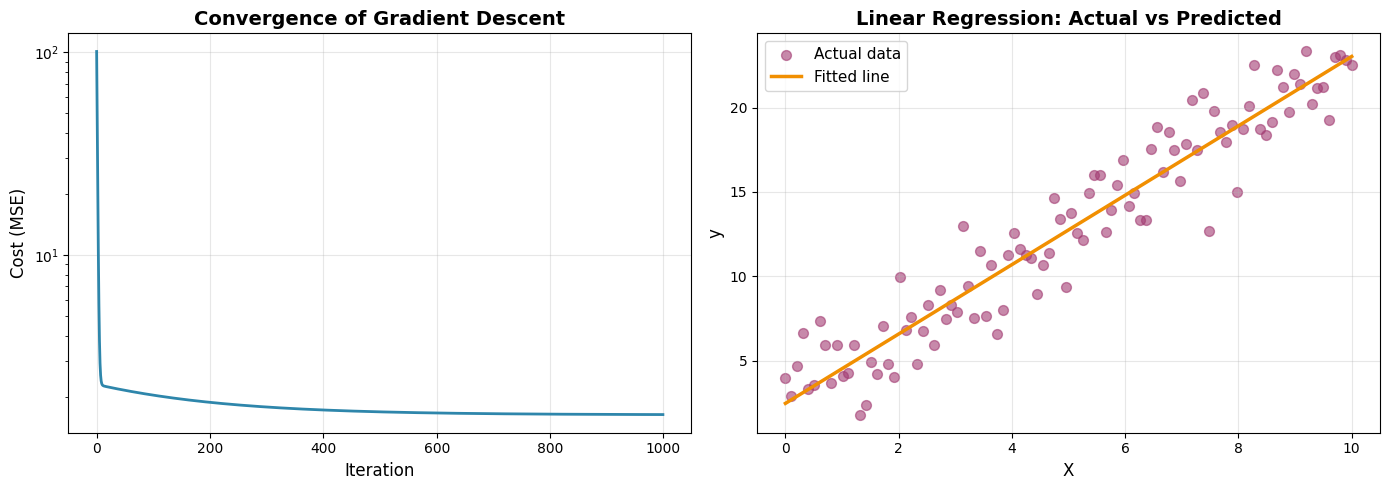

Visualization complete!


In [6]:
# Visualize the cost function convergence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Cost vs Iteration
axes[0].plot(cost_history, linewidth=2, color='#2E86AB')
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('Cost (MSE)', fontsize=12)
axes[0].set_title('Convergence of Gradient Descent', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Plot 2: Fitted line vs actual data
axes[1].scatter(X, y, alpha=0.6, s=50, label='Actual data', color='#A23B72')
y_pred = X_with_bias.dot(theta_optimal)
axes[1].plot(X, y_pred, color='#F18F01', linewidth=2.5, label='Fitted line')
axes[1].set_xlabel('X', fontsize=12)
axes[1].set_ylabel('y', fontsize=12)
axes[1].set_title('Linear Regression: Actual vs Predicted', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Visualization complete!")

### 1.3 Variants of Gradient Descent

There are three main variants of gradient descent, differing in how much data is used to compute the gradient:

#### 1. **Batch Gradient Descent (BGD)**
- Uses the entire dataset to compute the gradient
- Advantages: Stable convergence, guaranteed to find the global minimum (for convex functions)
- Disadvantages: Slow for large datasets, requires all data in memory

#### 2. **Stochastic Gradient Descent (SGD)**
- Uses one sample at a time to compute the gradient
- Advantages: Fast, can handle streaming data, can escape local minima
- Disadvantages: Noisy updates, may not converge smoothly

#### 3. **Mini-Batch Gradient Descent**
- Uses a small random subset (batch) of data to compute the gradient
- Advantages: Balance between stability and speed, good for GPU acceleration
- Disadvantages: Requires tuning batch size

| Aspect | BGD | SGD | Mini-Batch |
|--------|-----|-----|------------|
| Data per iteration | All | 1 | Batch size |
| Convergence | Smooth | Noisy | Balanced |
| Speed | Slow | Fast | Medium |
| Memory | High | Low | Medium |
| Practical use | Small datasets | Large datasets | Most common |


In [7]:
def stochastic_gradient_descent(X, y, learning_rate=0.01, num_iterations=1000, verbose=True):
    """
    Perform Stochastic Gradient Descent (SGD).
    
    Parameters:
    -----------
    X : ndarray of shape (m, n)
        Feature matrix
    y : ndarray of shape (m,)
        Target values
    learning_rate : float, default=0.01
        Step size for parameter updates
    num_iterations : int, default=1000
        Number of iterations (epochs)
    verbose : bool, default=True
        Print progress information
    
    Returns:
    --------
    theta : ndarray of shape (n,)
        Optimized parameters
    cost_history : list
        Cost at each iteration
    """
    m, n = X.shape
    theta = np.zeros(n)
    cost_history = []
    
    for iteration in range(num_iterations):
        # Shuffle the data
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        
        # Update parameters for each sample
        for i in range(m):
            X_i = X_shuffled[i:i+1]
            y_i = y_shuffled[i:i+1]
            
            gradient = compute_gradient(X_i, y_i, theta)
            theta = theta - learning_rate * gradient
        
        # Compute cost for the entire dataset
        cost = compute_cost(X, y, theta)
        cost_history.append(cost)
        
        if verbose and (iteration % 100 == 0 or iteration == num_iterations - 1):
            print(f"Epoch {iteration}: Cost = {cost:.6f}")
    
    return theta, cost_history

print("SGD function defined.")

SGD function defined.


In [8]:
def mini_batch_gradient_descent(X, y, learning_rate=0.01, num_iterations=1000, batch_size=16, verbose=True):
    """
    Perform Mini-Batch Gradient Descent.
    
    Parameters:
    -----------
    X : ndarray of shape (m, n)
        Feature matrix
    y : ndarray of shape (m,)
        Target values
    learning_rate : float, default=0.01
        Step size for parameter updates
    num_iterations : int, default=1000
        Number of iterations (epochs)
    batch_size : int, default=16
        Number of samples per batch
    verbose : bool, default=True
        Print progress information
    
    Returns:
    --------
    theta : ndarray of shape (n,)
        Optimized parameters
    cost_history : list
        Cost at each iteration
    """
    m, n = X.shape
    theta = np.zeros(n)
    cost_history = []
    
    for iteration in range(num_iterations):
        # Shuffle the data
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        
        # Process mini-batches
        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]
            
            gradient = compute_gradient(X_batch, y_batch, theta)
            theta = theta - learning_rate * gradient
        
        # Compute cost for the entire dataset
        cost = compute_cost(X, y, theta)
        cost_history.append(cost)
        
        if verbose and (iteration % 100 == 0 or iteration == num_iterations - 1):
            print(f"Epoch {iteration}: Cost = {cost:.6f}")
    
    return theta, cost_history

print("Mini-batch GD function defined.")

Mini-batch GD function defined.


In [9]:
# Compare all three variants
print("Training with Batch Gradient Descent...")
theta_bgd, cost_bgd = gradient_descent(X_with_bias, y, learning_rate=0.01, num_iterations=200, verbose=False)

print("\nTraining with Stochastic Gradient Descent...")
theta_sgd, cost_sgd = stochastic_gradient_descent(X_with_bias, y, learning_rate=0.01, num_iterations=200, verbose=False)

print("\nTraining with Mini-Batch Gradient Descent...")
theta_mb, cost_mb = mini_batch_gradient_descent(X_with_bias, y, learning_rate=0.01, num_iterations=200, batch_size=16, verbose=False)

print("\nAll variants trained successfully!")

Training with Batch Gradient Descent...

Training with Stochastic Gradient Descent...

Training with Mini-Batch Gradient Descent...

All variants trained successfully!


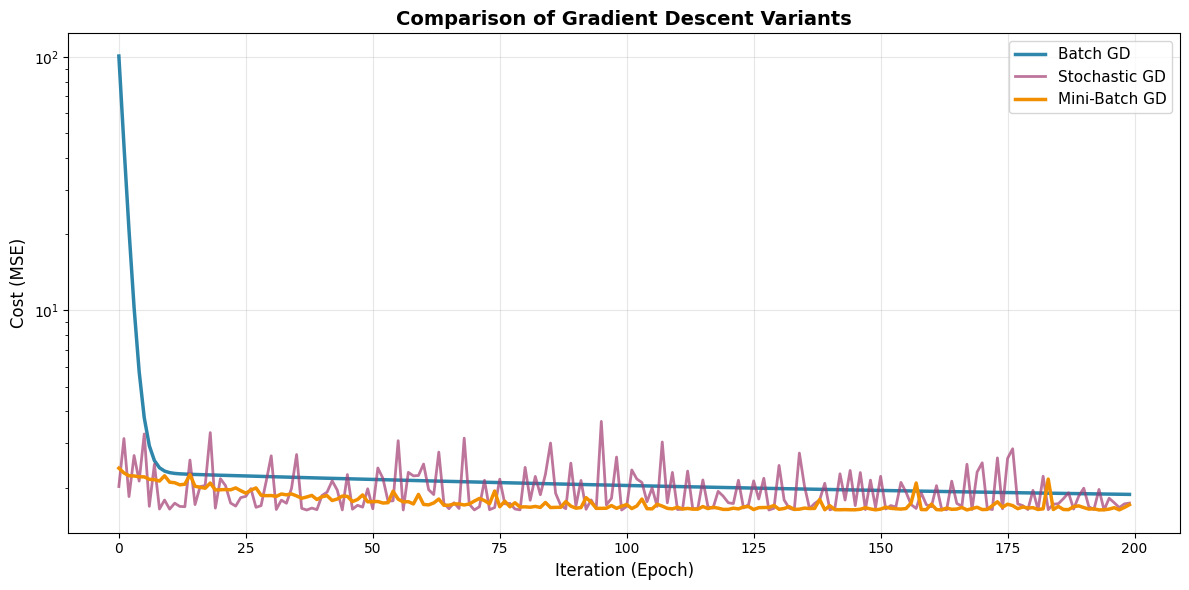

Comparison visualization complete!


In [10]:
# Visualize comparison of all three variants
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(cost_bgd, label='Batch GD', linewidth=2.5, color='#2E86AB')
ax.plot(cost_sgd, label='Stochastic GD', linewidth=2, alpha=0.7, color='#A23B72')
ax.plot(cost_mb, label='Mini-Batch GD', linewidth=2.5, color='#F18F01')

ax.set_xlabel('Iteration (Epoch)', fontsize=12)
ax.set_ylabel('Cost (MSE)', fontsize=12)
ax.set_title('Comparison of Gradient Descent Variants', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

print("Comparison visualization complete!")

### 1.4 Impact of Learning Rate

The learning rate ($\alpha$) is a critical hyperparameter that controls the step size in gradient descent. Its value significantly affects convergence:

- **Too small**: Convergence is very slow, requiring many iterations
- **Too large**: The algorithm may overshoot the minimum or diverge
- **Optimal**: Balances speed and stability

Let's visualize the impact of different learning rates.

Training with learning rate = 0.001...
Training with learning rate = 0.01...
Training with learning rate = 0.05...
Training with learning rate = 0.1...
Training with learning rate = 0.5...


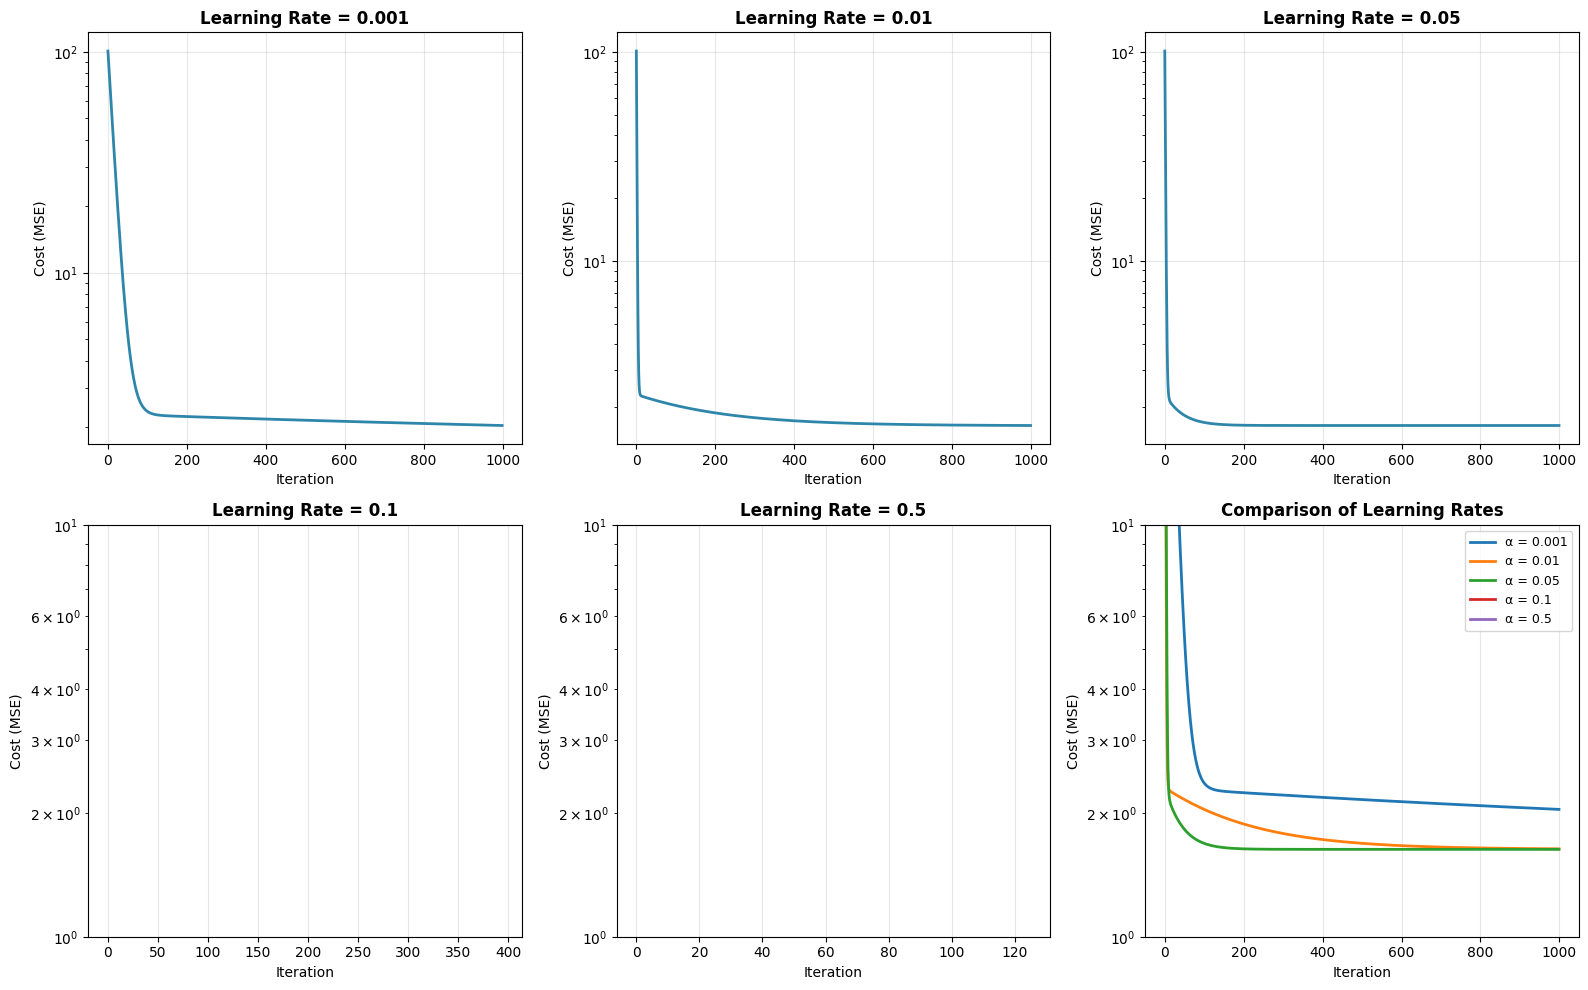

Learning rate analysis complete!


In [11]:
# Test different learning rates
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.5]
results = {}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, lr in enumerate(learning_rates):
    print(f"Training with learning rate = {lr}...")
    theta, cost_hist = gradient_descent(X_with_bias, y, learning_rate=lr, num_iterations=1000, verbose=False)
    results[lr] = cost_hist
    
    # Plot individual learning rate performance
    axes[idx].plot(cost_hist, linewidth=2, color='#2E86AB')
    axes[idx].set_xlabel('Iteration', fontsize=10)
    axes[idx].set_ylabel('Cost (MSE)', fontsize=10)
    axes[idx].set_title(f'Learning Rate = {lr}', fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_yscale('log')

# Comparison plot
ax = axes[5]
for lr in learning_rates:
    ax.plot(results[lr], label=f'α = {lr}', linewidth=2)
ax.set_xlabel('Iteration', fontsize=10)
ax.set_ylabel('Cost (MSE)', fontsize=10)
ax.set_title('Comparison of Learning Rates', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

print("Learning rate analysis complete!")

### 1.5 Advanced Optimizers

Beyond basic gradient descent, several advanced optimizers have been developed to improve convergence:

#### **Momentum**
Accumulates a velocity vector in the direction of persistent gradient descent, accelerating convergence.

$$v_t = \beta v_{t-1} + (1-\beta) \nabla J(\theta)$$
$$\theta = \theta - \alpha v_t$$

#### **RMSprop (Root Mean Square Propagation)**
Adapts the learning rate for each parameter based on the magnitude of recent gradients.

$$s_t = \beta s_{t-1} + (1-\beta) (\nabla J(\theta))^2$$
$$\theta = \theta - \frac{\alpha}{\sqrt{s_t + \epsilon}} \nabla J(\theta)$$

#### **Adam (Adaptive Moment Estimation)**
Combines momentum and RMSprop, widely used in deep learning.

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) \nabla J(\theta)$$
$$s_t = \beta_2 s_{t-1} + (1-\beta_2) (\nabla J(\theta))^2$$
$$\theta = \theta - \alpha \frac{m_t}{\sqrt{s_t} + \epsilon}$$

| Optimizer | Advantages | Disadvantages |
|-----------|------------|---------------|
| SGD | Simple, interpretable | Slow convergence, sensitive to learning rate |
| Momentum | Faster convergence | Requires tuning momentum parameter |
| RMSprop | Adaptive learning rate | More hyperparameters |
| Adam | Fast, adaptive, robust | More complex, more hyperparameters |


In [12]:
def gradient_descent_momentum(X, y, learning_rate=0.01, momentum=0.9, num_iterations=1000, verbose=True):
    """
    Gradient Descent with Momentum.
    """
    m, n = X.shape
    theta = np.zeros(n)
    velocity = np.zeros(n)
    cost_history = []
    
    for iteration in range(num_iterations):
        cost = compute_cost(X, y, theta)
        cost_history.append(cost)
        
        gradient = compute_gradient(X, y, theta)
        velocity = momentum * velocity + (1 - momentum) * gradient
        theta = theta - learning_rate * velocity
        
        if verbose and (iteration % 100 == 0 or iteration == num_iterations - 1):
            print(f"Iteration {iteration}: Cost = {cost:.6f}")
    
    return theta, cost_history

def gradient_descent_adam(X, y, learning_rate=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8, num_iterations=1000, verbose=True):
    """
    Gradient Descent with Adam Optimizer.
    """
    m, n = X.shape
    theta = np.zeros(n)
    m_t = np.zeros(n)  # First moment (mean)
    v_t = np.zeros(n)  # Second moment (variance)
    cost_history = []
    
    for iteration in range(num_iterations):
        cost = compute_cost(X, y, theta)
        cost_history.append(cost)
        
        gradient = compute_gradient(X, y, theta)
        
        # Update biased first moment estimate
        m_t = beta1 * m_t + (1 - beta1) * gradient
        # Update biased second raw moment estimate
        v_t = beta2 * v_t + (1 - beta2) * (gradient ** 2)
        
        # Compute bias-corrected first moment estimate
        m_t_hat = m_t / (1 - beta1 ** (iteration + 1))
        # Compute bias-corrected second raw moment estimate
        v_t_hat = v_t / (1 - beta2 ** (iteration + 1))
        
        # Update parameters
        theta = theta - learning_rate * m_t_hat / (np.sqrt(v_t_hat) + epsilon)
        
        if verbose and (iteration % 100 == 0 or iteration == num_iterations - 1):
            print(f"Iteration {iteration}: Cost = {cost:.6f}")
    
    return theta, cost_history

print("Advanced optimizer functions defined.")

Advanced optimizer functions defined.


In [13]:
# Compare optimizers
print("Training with Momentum...")
theta_mom, cost_mom = gradient_descent_momentum(X_with_bias, y, learning_rate=0.01, momentum=0.9, num_iterations=200, verbose=False)

print("\nTraining with Adam...")
theta_adam, cost_adam = gradient_descent_adam(X_with_bias, y, learning_rate=0.01, num_iterations=200, verbose=False)

print("\nOptimizers trained successfully!")

Training with Momentum...

Training with Adam...

Optimizers trained successfully!


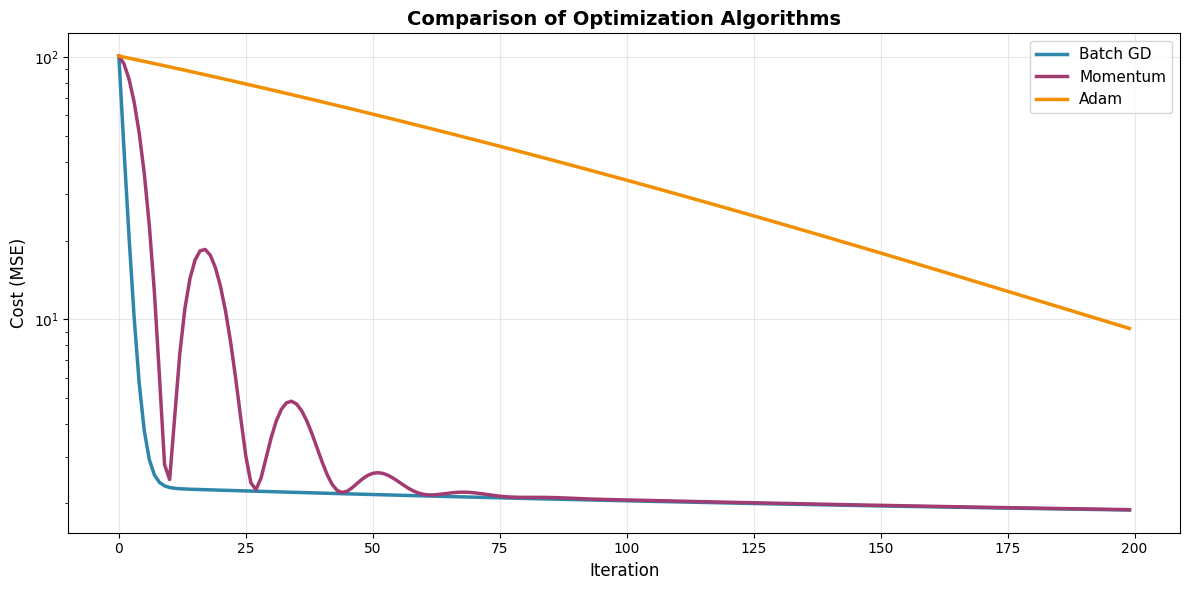

Optimizer comparison complete!


In [14]:
# Visualize optimizer comparison
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(cost_bgd, label='Batch GD', linewidth=2.5, color='#2E86AB')
ax.plot(cost_mom, label='Momentum', linewidth=2.5, color='#A23B72')
ax.plot(cost_adam, label='Adam', linewidth=2.5, color='#F18F01')

ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Cost (MSE)', fontsize=12)
ax.set_title('Comparison of Optimization Algorithms', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

print("Optimizer comparison complete!")

---

## Part 2: Feature Scaling

### 2.1 Introduction to Feature Scaling

**Feature Scaling** (also called **Normalization** or **Standardization**) is a preprocessing technique that transforms features to a common scale. This is crucial for many machine learning algorithms.

#### Why Feature Scaling Matters:

1. **Gradient Descent Convergence**: Features with different scales can cause gradient descent to take longer to converge
2. **Distance-Based Algorithms**: Algorithms like KNN, K-Means, and SVM are sensitive to feature magnitudes
3. **Regularization**: Regularization penalties (L1, L2) are affected by feature scales
4. **Neural Networks**: Scaled features help neural networks train faster and more stably

#### Common Scaling Techniques:

| Technique | Formula | Range | When to Use |
|-----------|---------|-------|-------------|
| **Standardization (Z-score)** | $z = \frac{x - \mu}{\sigma}$ | (-∞, +∞) | Normal distribution, linear models |
| **Min-Max Scaling** | $x' = \frac{x - x_{min}}{x_{max} - x_{min}}$ | [0, 1] | Bounded range needed |
| **Mean Normalization** | $x' = \frac{x - \mu}{x_{max} - x_{min}}$ | [-1, 1] | Alternative to standardization |
| **Robust Scaling** | $x' = \frac{x - Q_2}{Q_3 - Q_1}$ | Varies | Outliers present |
| **Log Scaling** | $x' = \log(x)$ | Varies | Skewed distributions |


### 2.2 Implementing Feature Scaling Techniques

In [15]:
# Create a sample dataset with different feature scales
np.random.seed(42)

# Feature 1: Age (0-100)
age = np.random.uniform(18, 80, 100)

# Feature 2: Salary (20,000 - 200,000)
salary = np.random.uniform(20000, 200000, 100)

# Feature 3: Experience (0-50)
experience = np.random.uniform(0, 50, 100)

# Combine features
X_unscaled = np.column_stack([age, salary, experience])

print("Unscaled Data Statistics:")
print("="*60)
feature_names = ['Age', 'Salary', 'Experience']
for i, name in enumerate(feature_names):
    print(f"{name}:")
    print(f"  Min: {X_unscaled[:, i].min():.2f}")
    print(f"  Max: {X_unscaled[:, i].max():.2f}")
    print(f"  Mean: {X_unscaled[:, i].mean():.2f}")
    print(f"  Std: {X_unscaled[:, i].std():.2f}")
    print()

Unscaled Data Statistics:
Age:
  Min: 18.34
  Max: 79.19
  Mean: 47.15
  Std: 18.35

Salary:
  Min: 21251.38
  Max: 197417.08
  Mean: 109609.71
  Std: 52495.56

Experience:
  Min: 0.25
  Max: 49.50
  Mean: 25.88
  Std: 14.60



In [16]:
def standardization(X):
    """
    Standardization (Z-score normalization).
    Transforms features to have mean 0 and standard deviation 1.
    
    Formula: z = (x - μ) / σ
    """
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    X_scaled = (X - mean) / std
    return X_scaled, mean, std

def min_max_scaling(X):
    """
    Min-Max Scaling (Normalization).
    Scales features to a fixed range [0, 1].
    
    Formula: x' = (x - x_min) / (x_max - x_min)
    """
    x_min = X.min(axis=0)
    x_max = X.max(axis=0)
    X_scaled = (X - x_min) / (x_max - x_min)
    return X_scaled, x_min, x_max

def mean_normalization(X):
    """
    Mean Normalization.
    Scales features to range [-1, 1].
    
    Formula: x' = (x - μ) / (x_max - x_min)
    """
    mean = X.mean(axis=0)
    x_min = X.min(axis=0)
    x_max = X.max(axis=0)
    X_scaled = (X - mean) / (x_max - x_min)
    return X_scaled, mean, x_min, x_max

def robust_scaling(X):
    """
    Robust Scaling.
    Uses median and interquartile range, robust to outliers.
    
    Formula: x' = (x - Q2) / (Q3 - Q1)
    """
    Q1 = np.percentile(X, 25, axis=0)
    Q2 = np.percentile(X, 50, axis=0)  # Median
    Q3 = np.percentile(X, 75, axis=0)
    X_scaled = (X - Q2) / (Q3 - Q1)
    return X_scaled, Q1, Q2, Q3

print("Scaling functions defined.")

Scaling functions defined.


In [17]:
# Apply all scaling techniques
X_standardized, std_mean, std_std = standardization(X_unscaled)
X_minmax, minmax_min, minmax_max = min_max_scaling(X_unscaled)
X_meannorm, meannorm_mean, meannorm_min, meannorm_max = mean_normalization(X_unscaled)
X_robust, robust_q1, robust_q2, robust_q3 = robust_scaling(X_unscaled)

print("All scaling techniques applied successfully!")

All scaling techniques applied successfully!


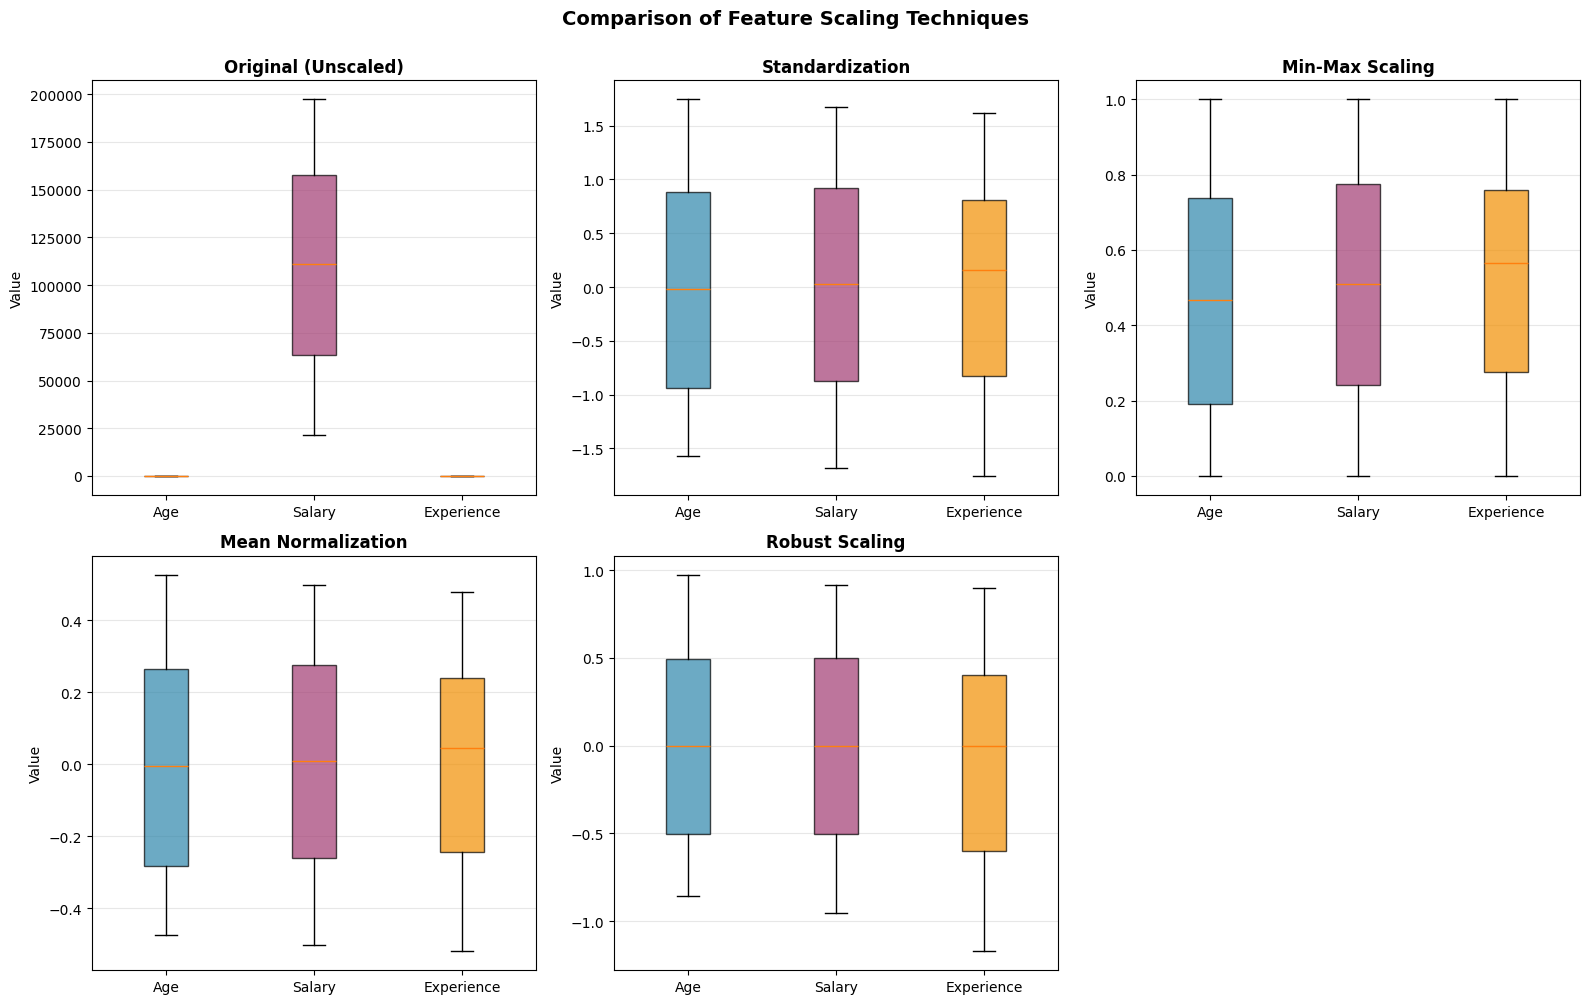

Scaling comparison visualization complete!


In [18]:
# Visualize the effect of different scaling techniques
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

scaling_methods = [
    ('Original (Unscaled)', X_unscaled),
    ('Standardization', X_standardized),
    ('Min-Max Scaling', X_minmax),
    ('Mean Normalization', X_meannorm),
    ('Robust Scaling', X_robust),
]

for idx, (method_name, X_data) in enumerate(scaling_methods):
    ax = axes.flatten()[idx]
    
    # Create box plots
    bp = ax.boxplot([X_data[:, i] for i in range(3)], 
                     labels=feature_names,
                     patch_artist=True)
    
    # Color the boxes
    colors = ['#2E86AB', '#A23B72', '#F18F01']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_title(method_name, fontsize=12, fontweight='bold')
    ax.set_ylabel('Value', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

# Remove the extra subplot
fig.delaxes(axes.flatten()[5])

plt.suptitle('Comparison of Feature Scaling Techniques', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("Scaling comparison visualization complete!")

In [19]:
# Print statistics for each scaling method
print("\n" + "="*80)
print("SCALED DATA STATISTICS")
print("="*80)

scaling_results = {
    'Standardization': X_standardized,
    'Min-Max Scaling': X_minmax,
    'Mean Normalization': X_meannorm,
    'Robust Scaling': X_robust,
}

for method_name, X_data in scaling_results.items():
    print(f"\n{method_name}:")
    print("-" * 60)
    for i, name in enumerate(feature_names):
        print(f"{name}:")
        print(f"  Min: {X_data[:, i].min():.4f}")
        print(f"  Max: {X_data[:, i].max():.4f}")
        print(f"  Mean: {X_data[:, i].mean():.4f}")
        print(f"  Std: {X_data[:, i].std():.4f}")


SCALED DATA STATISTICS

Standardization:
------------------------------------------------------------
Age:
  Min: -1.5698
  Max: 1.7456
  Mean: -0.0000
  Std: 1.0000
Salary:
  Min: -1.6832
  Max: 1.6727
  Mean: -0.0000
  Std: 1.0000
Experience:
  Min: -1.7555
  Max: 1.6182
  Mean: 0.0000
  Std: 1.0000

Min-Max Scaling:
------------------------------------------------------------
Age:
  Min: 0.0000
  Max: 1.0000
  Mean: 0.4735
  Std: 0.3016
Salary:
  Min: 0.0000
  Max: 1.0000
  Mean: 0.5016
  Std: 0.2980
Experience:
  Min: 0.0000
  Max: 1.0000
  Mean: 0.5203
  Std: 0.2964

Mean Normalization:
------------------------------------------------------------
Age:
  Min: -0.4735
  Max: 0.5265
  Mean: -0.0000
  Std: 0.3016
Salary:
  Min: -0.5016
  Max: 0.4984
  Mean: -0.0000
  Std: 0.2980
Experience:
  Min: -0.5203
  Max: 0.4797
  Mean: 0.0000
  Std: 0.2964

Robust Scaling:
------------------------------------------------------------
Age:
  Min: -0.8540
  Max: 0.9734
  Mean: 0.0112
  Std: 0.55

### 2.3 Impact of Feature Scaling on Gradient Descent

One of the most important benefits of feature scaling is its impact on gradient descent convergence. Let's demonstrate this with a practical example.

In [20]:
# Create a dataset where features have very different scales
np.random.seed(42)
n_samples = 100

# Feature 1: Small scale (0-10)
X1 = np.random.uniform(0, 10, n_samples)

# Feature 2: Large scale (0-10000)
X2 = np.random.uniform(0, 10000, n_samples)

# Create target: y = 2*X1 + 0.001*X2 + noise
y_true = 2 * X1 + 0.001 * X2 + np.random.normal(0, 50, n_samples)

# Prepare data with bias term
X_unscaled_gd = np.c_[np.ones(n_samples), X1, X2]

# Scale the features
X_scaled_gd = X_unscaled_gd.copy()
X_scaled_gd[:, 1:] = (X_unscaled_gd[:, 1:] - X_unscaled_gd[:, 1:].mean(axis=0)) / X_unscaled_gd[:, 1:].std(axis=0)

print("Dataset created for convergence comparison.")
print(f"Unscaled feature ranges: X1 = [0, 10], X2 = [0, 10000]")
print(f"True parameters: β0 = 0, β1 = 2, β2 = 0.001")

Dataset created for convergence comparison.
Unscaled feature ranges: X1 = [0, 10], X2 = [0, 10000]
True parameters: β0 = 0, β1 = 2, β2 = 0.001


In [21]:
# Train on unscaled data
print("\nTraining on UNSCALED data...")
theta_unscaled, cost_unscaled = gradient_descent(
    X_unscaled_gd, y_true, 
    learning_rate=0.0001,  # Very small learning rate needed
    num_iterations=1000,
    verbose=False
)

# Train on scaled data
print("Training on SCALED data...")
theta_scaled, cost_scaled = gradient_descent(
    X_scaled_gd, y_true, 
    learning_rate=0.01,  # Can use larger learning rate
    num_iterations=1000,
    verbose=False
)

print("\nTraining complete!")


Training on UNSCALED data...
Training on SCALED data...

Training complete!


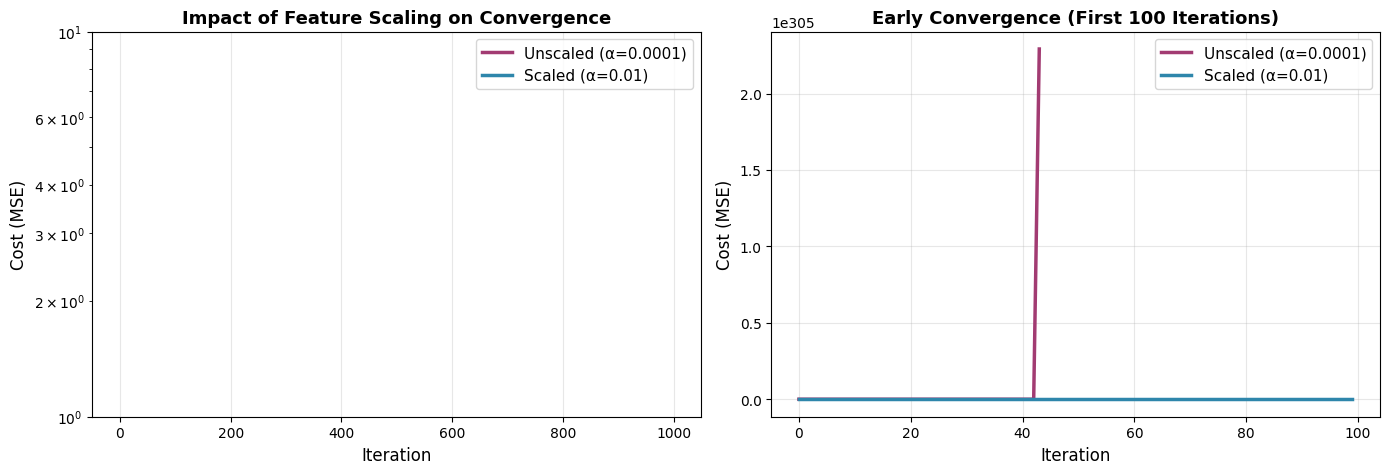

Convergence comparison visualization complete!


In [22]:
# Visualize the impact of scaling on convergence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Cost convergence comparison
axes[0].plot(cost_unscaled, label='Unscaled (α=0.0001)', linewidth=2.5, color='#A23B72')
axes[0].plot(cost_scaled, label='Scaled (α=0.01)', linewidth=2.5, color='#2E86AB')
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('Cost (MSE)', fontsize=12)
axes[0].set_title('Impact of Feature Scaling on Convergence', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Plot 2: Zoomed in on first 100 iterations
axes[1].plot(cost_unscaled[:100], label='Unscaled (α=0.0001)', linewidth=2.5, color='#A23B72')
axes[1].plot(cost_scaled[:100], label='Scaled (α=0.01)', linewidth=2.5, color='#2E86AB')
axes[1].set_xlabel('Iteration', fontsize=12)
axes[1].set_ylabel('Cost (MSE)', fontsize=12)
axes[1].set_title('Early Convergence (First 100 Iterations)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Convergence comparison visualization complete!")

In [23]:
# Print convergence statistics
print("\n" + "="*70)
print("CONVERGENCE ANALYSIS")
print("="*70)

# Find iteration where cost drops below certain thresholds
thresholds = [cost_unscaled[-1] * 2, cost_unscaled[-1] * 1.5, cost_unscaled[-1] * 1.1]

print("\nIterations to reach target cost:")
print("-" * 70)

for threshold in thresholds:
    iter_unscaled = np.where(np.array(cost_unscaled) <= threshold)[0]
    iter_scaled = np.where(np.array(cost_scaled) <= threshold)[0]
    
    iter_unscaled = iter_unscaled[0] if len(iter_unscaled) > 0 else 'Not reached'
    iter_scaled = iter_scaled[0] if len(iter_scaled) > 0 else 'Not reached'
    
    print(f"\nTarget cost: {threshold:.2f}")
    print(f"  Unscaled: Iteration {iter_unscaled}")
    print(f"  Scaled:   Iteration {iter_scaled}")

print(f"\n\nFinal costs:")
print("-" * 70)
print(f"Unscaled: {cost_unscaled[-1]:.4f}")
print(f"Scaled:   {cost_scaled[-1]:.4f}")


CONVERGENCE ANALYSIS

Iterations to reach target cost:
----------------------------------------------------------------------

Target cost: nan
  Unscaled: Iteration Not reached
  Scaled:   Iteration Not reached

Target cost: nan
  Unscaled: Iteration Not reached
  Scaled:   Iteration Not reached

Target cost: nan
  Unscaled: Iteration Not reached
  Scaled:   Iteration Not reached


Final costs:
----------------------------------------------------------------------
Unscaled: nan
Scaled:   1182.0898


### 2.4 Feature Scaling with Scikit-Learn

In practice, you'll often use scikit-learn's preprocessing utilities for feature scaling. Let's explore the main scalers.

In [24]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("Scikit-learn imported successfully!")

Scikit-learn imported successfully!


In [25]:
# Create a more realistic dataset
np.random.seed(42)
n_samples = 200

# Features with different scales
age = np.random.uniform(20, 70, n_samples)
salary = np.random.uniform(30000, 150000, n_samples)
years_experience = np.random.uniform(0, 40, n_samples)

# Target: Performance score (0-100)
performance = 20 + 0.5*age + 0.0001*salary + 2*years_experience + np.random.normal(0, 5, n_samples)
performance = np.clip(performance, 0, 100)

X_data = np.column_stack([age, salary, years_experience])
y_data = performance

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 160
Test set size: 40


In [26]:
# Train models with different scaling approaches
results = {}

# 1. No scaling
print("Training model WITHOUT scaling...")
model_no_scale = LinearRegression()
model_no_scale.fit(X_train, y_train)
y_pred_no_scale = model_no_scale.predict(X_test)
mse_no_scale = mean_squared_error(y_test, y_pred_no_scale)
r2_no_scale = r2_score(y_test, y_pred_no_scale)
results['No Scaling'] = {'MSE': mse_no_scale, 'R²': r2_no_scale}

# 2. StandardScaler
print("Training model with StandardScaler...")
scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)
model_std = LinearRegression()
model_std.fit(X_train_std, y_train)
y_pred_std = model_std.predict(X_test_std)
mse_std = mean_squared_error(y_test, y_pred_std)
r2_std = r2_score(y_test, y_pred_std)
results['StandardScaler'] = {'MSE': mse_std, 'R²': r2_std}

# 3. MinMaxScaler
print("Training model with MinMaxScaler...")
scaler_minmax = MinMaxScaler()
X_train_minmax = scaler_minmax.fit_transform(X_train)
X_test_minmax = scaler_minmax.transform(X_test)
model_minmax = LinearRegression()
model_minmax.fit(X_train_minmax, y_train)
y_pred_minmax = model_minmax.predict(X_test_minmax)
mse_minmax = mean_squared_error(y_test, y_pred_minmax)
r2_minmax = r2_score(y_test, y_pred_minmax)
results['MinMaxScaler'] = {'MSE': mse_minmax, 'R²': r2_minmax}

# 4. RobustScaler
print("Training model with RobustScaler...")
scaler_robust = RobustScaler()
X_train_robust = scaler_robust.fit_transform(X_train)
X_test_robust = scaler_robust.transform(X_test)
model_robust = LinearRegression()
model_robust.fit(X_train_robust, y_train)
y_pred_robust = model_robust.predict(X_test_robust)
mse_robust = mean_squared_error(y_test, y_pred_robust)
r2_robust = r2_score(y_test, y_pred_robust)
results['RobustScaler'] = {'MSE': mse_robust, 'R²': r2_robust}

print("\nAll models trained successfully!")

Training model WITHOUT scaling...
Training model with StandardScaler...
Training model with MinMaxScaler...
Training model with RobustScaler...

All models trained successfully!


In [55]:
# Train models with different scaling approaches
results = {}
from sklearn.linear_model import SGDRegressor
# 1. No scaling
print("Training model WITHOUT scaling...")
model_no_scale = SGDRegressor(learning_rate='constant')
model_no_scale.fit(X_train, y_train)
y_pred_no_scale = model_no_scale.predict(X_test)
mse_no_scale = mean_squared_error(y_test, y_pred_no_scale)
r2_no_scale = r2_score(y_test, y_pred_no_scale)
print(f"Number of iterations: {model_no_scale.n_iter_}")
results['No Scaling'] = {'MSE': mse_no_scale, 'R²': r2_no_scale}

# 2. StandardScaler
print("Training model with StandardScaler...")
scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)
model_std = SGDRegressor(learning_rate='constant')
model_std.fit(X_train_std, y_train)
y_pred_std = model_std.predict(X_test_std)
mse_std = mean_squared_error(y_test, y_pred_std)
r2_std = r2_score(y_test, y_pred_std)
print(f"Number of iterations: {model_std.n_iter_}")
results['StandardScaler'] = {'MSE': mse_std, 'R²': r2_std}

# 3. MinMaxScaler
print("Training model with MinMaxScaler...")
scaler_minmax = MinMaxScaler()
X_train_minmax = scaler_minmax.fit_transform(X_train)
X_test_minmax = scaler_minmax.transform(X_test)
model_minmax = SGDRegressor(learning_rate='constant')
model_minmax.fit(X_train_minmax, y_train)
y_pred_minmax = model_minmax.predict(X_test_minmax)
mse_minmax = mean_squared_error(y_test, y_pred_minmax)
r2_minmax = r2_score(y_test, y_pred_minmax)
print(f"Number of iterations: {model_minmax.n_iter_}")
results['MinMaxScaler'] = {'MSE': mse_minmax, 'R²': r2_minmax}

# 4. RobustScaler
print("Training model with RobustScaler...")
scaler_robust = RobustScaler()
X_train_robust = scaler_robust.fit_transform(X_train)
X_test_robust = scaler_robust.transform(X_test)
model_robust = SGDRegressor(learning_rate='constant')
model_robust.fit(X_train_robust, y_train)
y_pred_robust = model_robust.predict(X_test_robust)
mse_robust = mean_squared_error(y_test, y_pred_robust)
r2_robust = r2_score(y_test, y_pred_robust)
print(f"Number of iterations: {model_robust.n_iter_}")
results['RobustScaler'] = {'MSE': mse_robust, 'R²': r2_robust}

print("\nAll models trained successfully!")

Training model WITHOUT scaling...
Number of iterations: 15
Training model with StandardScaler...
Number of iterations: 11
Training model with MinMaxScaler...
Number of iterations: 25
Training model with RobustScaler...
Number of iterations: 26

All models trained successfully!


In [27]:
# Display results
print("\n" + "="*70)
print("MODEL PERFORMANCE COMPARISON")
print("="*70)
print(f"{'Scaling Method':<20} {'MSE':<15} {'R² Score':<15}")
print("-" * 70)

for method, metrics in results.items():
    print(f"{method:<20} {metrics['MSE']:<15.6f} {metrics['R²']:<15.6f}")

print("\nNote: For linear regression, scaling doesn't affect model performance,")
print("but it significantly affects convergence speed in gradient-based optimization.")


MODEL PERFORMANCE COMPARISON
Scaling Method       MSE             R² Score       
----------------------------------------------------------------------
No Scaling           53.329821       0.833305       
StandardScaler       53.329821       0.833305       
MinMaxScaler         53.329821       0.833305       
RobustScaler         53.329821       0.833305       

Note: For linear regression, scaling doesn't affect model performance,
but it significantly affects convergence speed in gradient-based optimization.


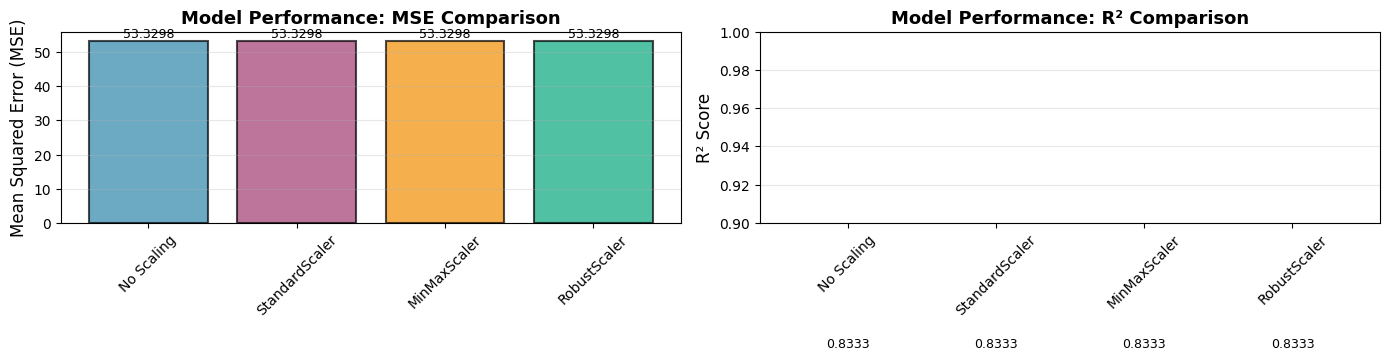

Performance comparison visualization complete!


In [28]:
# Visualize model performance comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

methods = list(results.keys())
mse_values = [results[m]['MSE'] for m in methods]
r2_values = [results[m]['R²'] for m in methods]

# Plot 1: MSE Comparison
colors = ['#2E86AB', '#A23B72', '#F18F01', '#06A77D']
bars1 = axes[0].bar(methods, mse_values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Mean Squared Error (MSE)', fontsize=12)
axes[0].set_title('Model Performance: MSE Comparison', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=9)

# Plot 2: R² Comparison
bars2 = axes[1].bar(methods, r2_values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('R² Score', fontsize=12)
axes[1].set_title('Model Performance: R² Comparison', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim([0.9, 1.0])

# Add value labels on bars
for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("Performance comparison visualization complete!")

### 2.5 When to Scale and When Not to Scale

#### Algorithms that REQUIRE or BENEFIT from scaling:
- **Distance-based**: KNN, K-Means, DBSCAN, SVM
- **Gradient-based**: Linear/Logistic Regression, Neural Networks, SVMs with kernel
- **Regularized models**: Ridge, Lasso, Elastic Net (L1/L2 penalties are scale-dependent)

#### Algorithms that are SCALE-INVARIANT:
- **Tree-based**: Decision Trees, Random Forests, Gradient Boosting, XGBoost
- **Rule-based**: Naive Bayes (for some variants)

#### Important Considerations:
1. **Fit scaler on training data only**: Always fit the scaler on training data and apply to test data
2. **Save the scaler**: For production, save the fitted scaler to apply to new data
3. **Feature interpretation**: Scaling changes feature coefficients; keep original scale for interpretation
4. **Outliers**: Use RobustScaler if data has outliers; StandardScaler is sensitive to outliers


In [29]:
# Demonstrate the importance of fitting scaler on training data only
print("="*70)
print("CORRECT vs INCORRECT SCALING PRACTICE")
print("="*70)

# INCORRECT: Fit scaler on entire dataset
print("\n❌ INCORRECT: Fitting scaler on entire dataset")
scaler_wrong = StandardScaler()
X_all_scaled = scaler_wrong.fit_transform(X_data)  # Fit on all data!
X_train_wrong = X_all_scaled[:len(X_train)]
X_test_wrong = X_all_scaled[len(X_train):]

print(f"Scaler mean: {scaler_wrong.mean_}")
print(f"Scaler scale: {scaler_wrong.scale_}")
print(f"This causes DATA LEAKAGE from test set to training!")

# CORRECT: Fit scaler on training data only
print("\n✓ CORRECT: Fitting scaler on training data only")
scaler_correct = StandardScaler()
X_train_correct = scaler_correct.fit_transform(X_train)  # Fit only on training data
X_test_correct = scaler_correct.transform(X_test)  # Apply to test data

print(f"Scaler mean: {scaler_correct.mean_}")
print(f"Scaler scale: {scaler_correct.scale_}")
print(f"No data leakage! Test data is transformed using training statistics.")

CORRECT vs INCORRECT SCALING PRACTICE

❌ INCORRECT: Fitting scaler on entire dataset
Scaler mean: [4.42003117e+01 9.05250163e+04 2.08269114e+01]
Scaler scale: [1.47076639e+01 3.50721325e+04 1.22615824e+01]
This causes DATA LEAKAGE from test set to training!

✓ CORRECT: Fitting scaler on training data only
Scaler mean: [4.40922353e+01 8.98768150e+04 2.10405671e+01]
Scaler scale: [1.47012722e+01 3.55942488e+04 1.21995677e+01]
No data leakage! Test data is transformed using training statistics.


In [30]:
# Compare tree-based vs linear models with scaling
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

print("\n" + "="*70)
print("SCALE-INVARIANT vs SCALE-DEPENDENT MODELS")
print("="*70)

# Linear model (scale-dependent)
print("\nLinear Regression (Scale-Dependent):")
print("-" * 70)

lr_unscaled = LinearRegression()
lr_unscaled.fit(X_train, y_train)
r2_lr_unscaled = lr_unscaled.score(X_test, y_test)
print(f"R² (unscaled): {r2_lr_unscaled:.6f}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_scaled = LinearRegression()
lr_scaled.fit(X_train_scaled, y_train)
r2_lr_scaled = lr_scaled.score(X_test_scaled, y_test)
print(f"R² (scaled):   {r2_lr_scaled:.6f}")
print(f"Difference: {abs(r2_lr_unscaled - r2_lr_scaled):.10f} (negligible)")

# Tree-based model (scale-invariant)
print("\nRandom Forest (Scale-Invariant):")
print("-" * 70)

rf_unscaled = RandomForestRegressor(n_estimators=100, random_state=42)
rf_unscaled.fit(X_train, y_train)
r2_rf_unscaled = rf_unscaled.score(X_test, y_test)
print(f"R² (unscaled): {r2_rf_unscaled:.6f}")

rf_scaled = RandomForestRegressor(n_estimators=100, random_state=42)
rf_scaled.fit(X_train_scaled, y_train)
r2_rf_scaled = rf_scaled.score(X_test_scaled, y_test)
print(f"R² (scaled):   {r2_rf_scaled:.6f}")
print(f"Difference: {abs(r2_rf_unscaled - r2_rf_scaled):.10f} (identical!)")


SCALE-INVARIANT vs SCALE-DEPENDENT MODELS

Linear Regression (Scale-Dependent):
----------------------------------------------------------------------
R² (unscaled): 0.833305
R² (scaled):   0.833305
Difference: 0.0000000000 (negligible)

Random Forest (Scale-Invariant):
----------------------------------------------------------------------
R² (unscaled): 0.948783
R² (scaled):   0.948783
Difference: 0.0000000000 (identical!)


---

## Summary and Key Takeaways

### Gradient Descent

1. **Core Concept**: Gradient descent is an iterative optimization algorithm that minimizes a cost function by taking steps proportional to the negative gradient.

2. **Update Rule**: $\theta_{new} = \theta_{old} - \alpha \cdot \nabla J(\theta)$

3. **Variants**:
   - **Batch GD**: Uses all data, stable but slow
   - **SGD**: Uses one sample, fast but noisy
   - **Mini-Batch GD**: Balance between speed and stability

4. **Learning Rate**: Critical hyperparameter affecting convergence speed and stability

5. **Advanced Optimizers**: Momentum, RMSprop, and Adam provide adaptive learning rates and faster convergence

### Feature Scaling

1. **Purpose**: Transform features to a common scale for improved model performance and convergence

2. **Common Techniques**:
   - **Standardization**: Mean 0, Std 1 (for normal distributions)
   - **Min-Max Scaling**: Range [0, 1] (when bounded range needed)
   - **Mean Normalization**: Range [-1, 1] (alternative to standardization)
   - **Robust Scaling**: Uses median and IQR (robust to outliers)

3. **When to Scale**:
   - Distance-based algorithms (KNN, K-Means, SVM)
   - Gradient-based algorithms (Linear/Logistic Regression, Neural Networks)
   - Regularized models (Ridge, Lasso)

4. **When NOT to Scale**:
   - Tree-based models (Decision Trees, Random Forests, XGBoost)

5. **Best Practice**: Fit scaler on training data only, then apply to test data to avoid data leakage

### Practical Recommendations

- Always explore your data before choosing a scaling method
- Use StandardScaler as the default for most cases
- Use RobustScaler if your data has significant outliers
- Monitor convergence during training to validate your learning rate choice
- Consider using advanced optimizers (Adam) for complex models
- Document your scaling parameters for reproducibility in production


---

## References and Further Reading

### Key Papers
1. Kingma, D. P., & Ba, J. (2014). Adam: A method for stochastic optimization. arXiv preprint arXiv:1412.6980.
2. Nesterov, Y. (1983). A method of solving a convex programming problem with convergence rate O(1/k²). Soviet Mathematics Doklady, 27(2), 372-376.
3. Tieleman, T., & Hinton, G. (2012). Lecture 6.5-rmsprop: Divide the gradient by a running average of its recent magnitude. COURSERA: Neural Networks for Machine Learning, 4(2), 26-31.

### Online Resources
- [Scikit-learn Preprocessing Documentation](https://scikit-learn.org/stable/modules/preprocessing.html)
- [Understanding Gradient Descent](https://developers.google.com/machine-learning/crash-course/reducing-loss/gradient-descent)
- [Feature Scaling for Machine Learning](https://machinelearningmastery.com/standardscaler-and-minmaxscaler-transforms-in-python/)

### Textbooks
- Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning. MIT Press.
- Murphy, K. P. (2012). Machine Learning: A Probabilistic Perspective. MIT Press.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). The Elements of Statistical Learning. Springer.


---

## Exercises for Practice

### Exercise 1: Gradient Descent Tuning
Modify the learning rate and number of iterations for the gradient descent algorithm. Observe how these hyperparameters affect convergence. What is the optimal learning rate for the given dataset?

### Exercise 2: Feature Scaling Impact
Create a dataset with features on very different scales (e.g., age 0-100, income 0-1,000,000). Train a linear regression model with and without scaling. Compare the convergence speed using gradient descent.

### Exercise 3: Optimizer Comparison
Implement additional optimizers like AdaGrad or Nadam. Compare their convergence behavior on a non-convex function.

### Exercise 4: Outlier Handling
Generate a dataset with outliers. Compare the performance of StandardScaler, MinMaxScaler, and RobustScaler. Which performs best?

### Exercise 5: Real-World Application
Download a real dataset from UCI Machine Learning Repository. Apply gradient descent with different scaling methods. Evaluate the impact on model performance.
